# DGA Detection: Autoencoder
The Autoencoder approach treats DGA detection as an unsupervised anomaly detection task. 
It is trained only on "normal" (benign) data. When it encounters a DGA domain, it will fail to reconstruct it accurately, 
resulting in a high "reconstruction error" (the anomaly score). This makes it much harder for new, unseen malware to by-pass the system.

## 1. Data Preparation

Filter the dataset so the model only sees benign domains during the training phase.

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import string
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

In [41]:
# Configuration and hyperparameters
MAX_SEQ_LEN = 75  
BATCH_SIZE = 128
LATENCY_REPS = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Vocab
VOCAB = string.ascii_lowercase + string.digits + "-."
stoi = {ch: i + 1 for i, ch in enumerate(VOCAB)} 
VOCAB_SIZE = len(stoi) + 1

# Encodes domain string into a fixed-length integer sequence
def encode_domain(domain, seq_len=MAX_SEQ_LEN):
    encoded = [stoi.get(c, 0) for c in str(domain).lower()]
    encoded = encoded[:seq_len]
    encoded += [0] * (seq_len - len(encoded))
    return encoded

# Load data
df = pd.read_csv("/Users/maryam/Downloads/dga_data.csv").dropna(subset=['domain'])
df['encoded'] = df['domain'].apply(encode_domain)

# Split into Benign (for training) and Full (for evaluation)
X_all = np.array(df['encoded'].tolist())
y_all = (df['isDGA'] == 'dga').astype(int).values

# Filter training set
X_train_benign = X_all[y_all == 0]
X_train, X_val = train_test_split(X_train_benign, test_size=0.1, random_state=42)

# Convert to PyTorch Tensors
train_tensor = torch.tensor(X_train, dtype=torch.long)
val_tensor = torch.tensor(X_val, dtype=torch.long)
test_full_tensor = torch.tensor(X_all, dtype=torch.long)

## 2. Autoencoder Model

Autoencoder for DGA detection.
Aim of the model is to compresses a domain string into a latent space and attempts to reconstruct it. 

The model consists of:

- Embedding layer
- Linear Encoder to compress the sequence
- Decoder to reconstruct the character logits.

In [68]:
class DGAAutoencoder(nn.Module):

    def __init__(self, vocab_size, embed_dim=32, hidden_dim=128, latent_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(embed_dim * MAX_SEQ_LEN, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim * MAX_SEQ_LEN)
        )
        
        self.output_layer = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        batch_size = x.size(0)
        # Embedding
        emb = self.embedding(x)
        
        # Encode
        latent = self.encoder(emb)
        
        # Decode
        reconstructed_flat = self.decoder(latent)
        reconstructed_emb = reconstructed_flat.view(batch_size, MAX_SEQ_LEN, -1)
        
        # Project to Logits
        logits = self.output_layer(reconstructed_emb)
        return logits

# Initialize Model
ae_model = DGAAutoencoder(VOCAB_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(ae_model.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss(reduction='none')

## 3. Training

Training on benign data focuses on minimizing the reconstruction loss for legitimate domain strings.

In [69]:
train_loader = DataLoader(train_tensor, batch_size=BATCH_SIZE, shuffle=True)

ae_model.train()

for epoch in range(10):
    epoch_loss = 0
    for batch in train_loader:
        x = batch.to(DEVICE)
        optimizer.zero_grad()

        logits = ae_model(x) 

        loss = criterion(logits.transpose(1, 2), x).mean()
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1:02d} | Avg Loss: {avg_epoch_loss:.6f}")

Epoch 01 | Avg Loss: 0.536474
Epoch 02 | Avg Loss: 0.198987
Epoch 03 | Avg Loss: 0.096466
Epoch 04 | Avg Loss: 0.058531
Epoch 05 | Avg Loss: 0.041894
Epoch 06 | Avg Loss: 0.033124
Epoch 07 | Avg Loss: 0.027898
Epoch 08 | Avg Loss: 0.024606
Epoch 09 | Avg Loss: 0.022023
Epoch 10 | Avg Loss: 0.019777


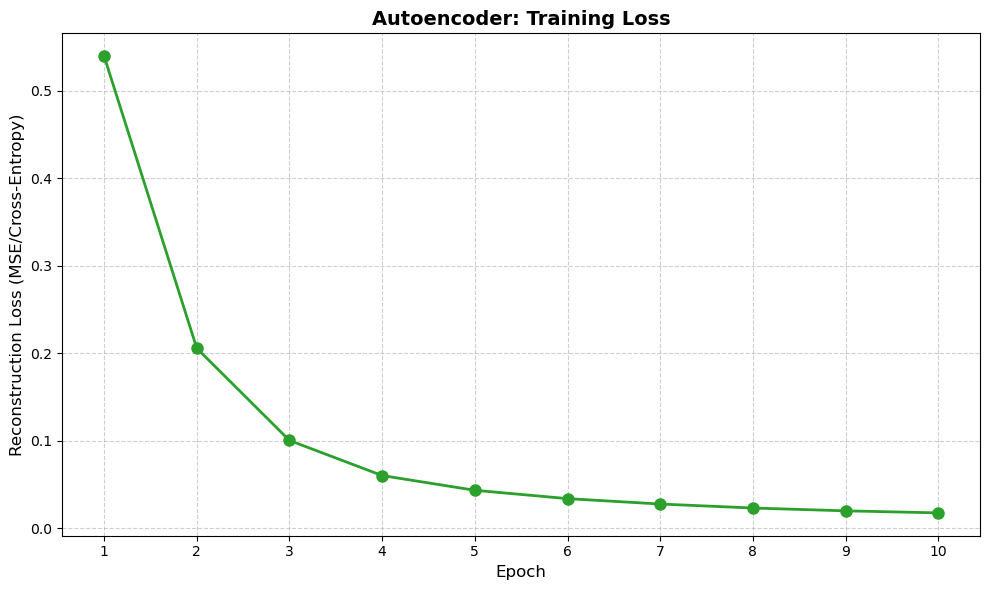

In [73]:
import matplotlib.pyplot as plt

# Data from your converged run
epochs = list(range(1, 11))
losses = [
    0.539320, 0.205747, 0.100501, 0.060401, 0.043577,
    0.034061, 0.027891, 0.023341, 0.020116, 0.017779
]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, marker='o', linestyle='-', color='#2ca02c', linewidth=2, markersize=8)

# Add titles and labels
plt.title('Autoencoder: Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE/Cross-Entropy)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Anomaly Detection & Inference Latency
Calculate the reconstruction error for the entire test set (benign + DGA) to find anomaly score.

In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

ae_model.eval()
test_loader = DataLoader(test_full_tensor, batch_size=256, shuffle=False)
anomaly_scores = []

start_time = time.perf_counter()
with torch.no_grad():
    for batch in test_loader:
        x = batch.to(DEVICE)
        logits = ae_model(x)

        char_losses = criterion(logits.transpose(1, 2), x)

        sample_losses = char_losses.mean(dim=1)
        anomaly_scores.extend(sample_losses.cpu().numpy())

total_time = (time.perf_counter() - start_time)
latency_ms = (total_time / len(X_all)) * 1000
anomaly_scores = np.array(anomaly_scores)

precisions, recalls, thresholds = precision_recall_curve(y_all, anomaly_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred = (anomaly_scores >= best_threshold).astype(int)

auc_roc = roc_auc_score(y_all, anomaly_scores)
pr_auc = average_precision_score(y_all, anomaly_scores)
precision = precision_score(y_all, y_pred)
recall = recall_score(y_all, y_pred)
f1 = f1_score(y_all, y_pred)

# False Positive Rate
tn, fp, fn, tp = confusion_matrix(y_all, y_pred).ravel()
fpr = fp / (fp + tn)

print(f"\n--- Autoencoder Results ---")
print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"AUC-ROC:           {auc_roc:.4f}")
print(f"PR-AUC:            {pr_auc:.4f}")
print(f"F1-Score:          {f1:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"FPR:               {fpr:.4f}")
print(f"Inference Latency: {latency_ms:.4f} ms/sample")
print(f"Parameter Count:   {sum(p.numel() for p in ae_model.parameters()):,}")


--- Autoencoder Results ---
Optimal Threshold: 0.0284
AUC-ROC:           0.8977
PR-AUC:            0.9192
F1-Score:          0.8538
Precision:         0.8672
Recall:            0.8409
FPR:               0.1288
Inference Latency: 0.0099 ms/sample
Parameter Count:   627,815


In [78]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix

ae_model.eval()
test_loader = DataLoader(test_full_tensor, batch_size=256, shuffle=False)
anomaly_scores = []

start_time = time.perf_counter()
with torch.no_grad():
    for batch in test_loader:
        x = batch.to(DEVICE)
        logits = ae_model(x)
        char_losses = criterion(logits.transpose(1, 2), x)
        sample_losses = char_losses.mean(dim=1)
        anomaly_scores.extend(sample_losses.cpu().numpy())

total_time = (time.perf_counter() - start_time)
global_mean_latency = (total_time / len(X_all)) * 1000
anomaly_scores = np.array(anomaly_scores)

precisions, recalls, thresholds = precision_recall_curve(y_all, anomaly_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred = (anomaly_scores >= best_threshold).astype(int)
auc_roc = roc_auc_score(y_all, anomaly_scores)
f1 = f1_score(y_all, y_pred)
prec = precision_score(y_all, y_pred)
rec = recall_score(y_all, y_pred)

tn, fp, fn, tp = confusion_matrix(y_all, y_pred).ravel()
fpr = fp / (fp + tn)

latencies = []
dummy_input = torch.randint(0, VOCAB_SIZE, (1, MAX_SEQ_LEN)).to(DEVICE)
for _ in range(1000):
    start = time.perf_counter()
    with torch.no_grad():
        _ = ae_model(dummy_input)
    latencies.append((time.perf_counter() - start) * 1000)

mean_lat = np.mean(latencies)
p99_lat = np.percentile(latencies, 99)
params = sum(p.numel() for p in ae_model.parameters())

final_results = pd.DataFrame({
    "Model": ["Autoencoder"],
    "Threshold": [f"{best_threshold:.6f}"],
    "AUC-ROC": [f"{auc_roc:.4f}"],
    "FPR": [f"{fpr:.4f}"],
    "Precision": [f"{prec:.4f}"],
    "Recall": [f"{rec:.4f}"],
    "F1": [f"{f1:.4f}"],
    "Parameters": [f"{params:,}"],
    "Mean Latency (ms)": [f"{mean_lat:.4f}"],
    "P99 Latency (ms)": [f"{p99_lat:.4f}"]
})

print("\n--- Autoencoder Final Evaluation ---")
display(final_results)


--- Autoencoder Final Evaluation ---


,Model,Threshold,AUC-ROC,FPR,Precision,Recall,F1,Parameters,Mean Latency (ms),P99 Latency (ms)
0,Autoencoder,0.028372,0.8977,0.1288,0.8672,0.8409,0.8538,"627,815",0.0744,0.1030
